# Desafío - Clasificación de calidad de ramen
## Daniel Rojas López

## Contexto del problema

El objetivo es construir un modelo de clasificación que determine si un paquete de ramen es **"bueno"** o **"malo"** en función de sus características específicas (marca, presentación y país de origen). El dataset `ramen-ratings.xlsx` contiene las evaluaciones de distintos productos de ramen, y aunque no incluye una etiqueta explícita, la variable `Stars` (calificación de 0 a 5) permite derivarla: un ramen con calificación **mayor o igual a 3,5** se considerará "bueno"; en caso contrario, "malo".

- **Unidad de análisis:** cada producto de ramen evaluado.
- **Variable objetivo:** `malo` (calificación < 3,5 = 1) vs `bueno` (calificación ≥ 3,5 = 0). La clase positiva es "malo" porque es el caso de interés y el minoritario que se desea detectar.
- **Tipo de problema:** clasificación binaria supervisada.
- **Metodología:** análisis exploratorio, limpieza y preprocesamiento, división en entrenamiento y prueba, entrenamiento de un baseline, Regresión Logística y SVM con optimización de hiperparámetros mediante validación cruzada, y evaluación con precisión, recall, F1 y AUC-ROC.

## 1. Análisis exploratorio de los datos

Se cargará el dataset y se explorarán sus características: dimensiones, tipos de datos, valores nulos, duplicados y la distribución de las variables.

In [1]:
# Se importarán las librerías necesarias y se cargará el dataset de calificaciones de ramen.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se configurará el estilo de los gráficos.
sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('ramen-ratings.xlsx')

# Se mostrarán las primeras filas del dataset.
df.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [2]:
# Se mostrará la información general del dataset: tipos de datos y cantidad de valores no nulos.
print('Dimensiones del dataset:', df.shape)
print('Filas duplicadas:', df.duplicated().sum())
print()
df.info()

Dimensiones del dataset: (2580, 7)
Filas duplicadas: 0

<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review #  2580 non-null   int64 
 1   Brand     2580 non-null   str   
 2   Variety   2580 non-null   str   
 3   Style     2578 non-null   str   
 4   Country   2580 non-null   str   
 5   Stars     2580 non-null   object
 6   Top Ten   41 non-null     str   
dtypes: int64(1), object(1), str(5)
memory usage: 141.2+ KB


In [3]:
# Se mostrará el resumen estadístico de las variables del dataset.
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Review #,2580.0,NaN,NaN,NaN,1290.5,744.926171,1.0,645.75,1290.5,1935.25,2580.0
Brand,2580,355,Nissin,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,2580,2412,Beef,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,2578,7,Pack,1531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,2580,38,Japan,352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stars,2580.0,43.0,4.0,393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top Ten,41,38,\n,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


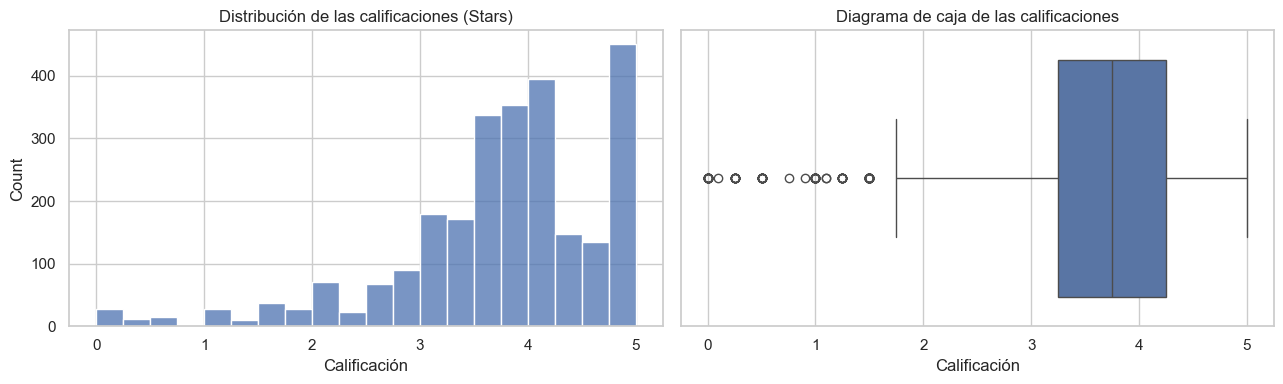

Valores no numéricos en Stars ("Unrated"): 3


In [4]:
# Se analizará la distribución de las calificaciones (Stars) y de los valores inválidos.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(pd.to_numeric(df['Stars'], errors='coerce'), bins=20, ax=axes[0])
axes[0].set_title('Distribución de las calificaciones (Stars)')
axes[0].set_xlabel('Calificación')

sns.boxplot(x=pd.to_numeric(df['Stars'], errors='coerce'), ax=axes[1])
axes[1].set_title('Diagrama de caja de las calificaciones')
axes[1].set_xlabel('Calificación')
plt.tight_layout()
plt.show()

print('Valores no numéricos en Stars ("Unrated"):', df['Stars'].eq('Unrated').sum())

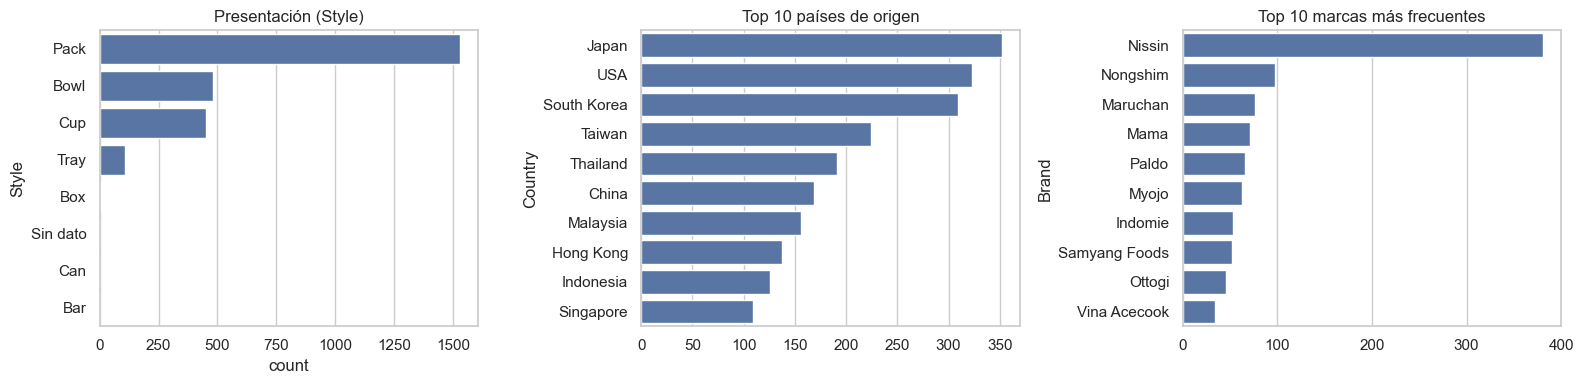

In [5]:
# Se analizará la distribución de las variables categóricas más relevantes.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

estilos = df['Style'].fillna('Sin dato')
sns.countplot(y=estilos, order=estilos.value_counts().index, ax=axes[0])
axes[0].set_title('Presentación (Style)')

top_paises = df['Country'].value_counts().head(10)
sns.barplot(y=top_paises.index, x=top_paises.values, ax=axes[1])
axes[1].set_title('Top 10 países de origen')

top_marcas = df['Brand'].value_counts().head(10)
sns.barplot(y=top_marcas.index, x=top_marcas.values, ax=axes[2])
axes[2].set_title('Top 10 marcas más frecuentes')
plt.tight_layout()
plt.show()

In [6]:
# Se cuantificarán los valores nulos y la cantidad de categorías por variable categórica.
print('Valores nulos por columna:')
print(df.isna().sum())
print()
print('Categorías únicas por columna:')
for col in ['Brand', 'Variety', 'Style', 'Country']:
    print(f'  {col}: {df[col].nunique()}')
print()
print('Registros con valor en Top Ten:', df['Top Ten'].notna().sum())

Valores nulos por columna:
Review #       0
Brand          0
Variety        0
Style          2
Country        0
Stars          0
Top Ten     2539
dtype: int64

Categorías únicas por columna:
  Brand: 355
  Variety: 2412
  Style: 7
  Country: 38

Registros con valor en Top Ten: 41


### Conclusiones del análisis exploratorio

- El dataset contiene **2.580 productos** y **7 columnas**, sin filas duplicadas.
- `Stars` tiene **3 valores inválidos** ("Unrated") que impiden definir la etiqueta de calidad.
- `Style` presenta **2 valores nulos**.
- `Top Ten` tiene **2.539 de 2.580 valores nulos** (ranking de años pasados), por lo que no aporta como característica.
- `Variety` tiene **2.412 categorías únicas en 2.580 filas**: es prácticamente un identificador por producto y usarla como variable predeciría por memorización (fuga de información).
- No existen calificaciones fuera del rango válido [0, 5]; no hay valores atípicos numéricos que corregir.

## 2. Preprocesamiento de los datos

Se limpiarán los datos (valores inválidos y nulos), se creará la variable objetivo a partir de `Stars`, se eliminarán las columnas que generan fuga de información y se codificarán las variables categóricas.

In [7]:
# Se creará una función reutilizable que transforma el dataset original en variables listas para modelar.
# La función no modifica el DataFrame de entrada y valida las conversiones críticas.

def preparar_datos(df):
    # Se trabajará sobre una copia para no modificar el DataFrame original.
    datos = df.copy()

    # Se eliminarán columnas que no aportan a la predicción:
    # - 'Review #': identificador de la fila (fuga de información).
    # - 'Top Ten': ranking con ~98% de valores nulos.
    # - 'Variety': casi un identificador por fila (2.412 únicos / 2.580), generaría memorización.
    datos = datos.drop(columns=['Review #', 'Top Ten', 'Variety'])

    # Se convertirá 'Stars' a numérico; los valores "Unrated" (3 casos) se transformarán en nulos.
    datos['Stars'] = pd.to_numeric(datos['Stars'], errors='coerce')

    # Se descartarán las filas sin calificación, ya que no permiten definir la etiqueta.
    datos = datos.dropna(subset=['Stars'])

    # Se imputarán los 2 nulos de 'Style' con su moda ('Pack').
    datos['Style'] = datos['Style'].fillna('Pack')

    # Se creará la variable objetivo: 'malo' (1) si Stars < 3,5, 'bueno' (0) en caso contrario.
    datos['objetivo'] = (datos['Stars'] < 3.5).astype(int)

    # Se codificarán las variables categóricas restantes mediante one-hot encoding.
    columnas_categoricas = ['Brand', 'Style', 'Country']
    X = pd.get_dummies(datos[columnas_categoricas], drop_first=True)

    # Variable objetivo.
    y = datos['objetivo']

    return X, y

# Se aplicará la función de preparación al dataset original.
X, y = preparar_datos(df)

print('Dimensiones de las características (X):', X.shape)
print('Cantidad de observaciones (y):', y.shape)
print('Sin valores nulos después de la limpieza:', X.isnull().sum().sum() == 0)
print()
print('Distribución de la variable objetivo:')
print(y.value_counts().rename({0: 'Bueno', 1: 'Malo'}))
print()
X.head()

Dimensiones de las características (X): (2577, 397)
Cantidad de observaciones (y): (2577,)
Sin valores nulos después de la limpieza: True

Distribución de la variable objetivo:
objetivo
Bueno    1818
Malo      759
Name: count, dtype: int64



,Brand_7 Select,Brand_7 Select/Nissin,Brand_A-One,Brand_A-Sha Dry Noodle,Brand_A1,Brand_ABC,Brand_Acecook,Brand_Adabi,Brand_Ah Lai,Brand_Ajinatori,...,Country_Sarawak,Country_Singapore,Country_South Korea,Country_Sweden,Country_Taiwan,Country_Thailand,Country_UK,Country_USA,Country_United States,Country_Vietnam
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Conclusiones del preprocesamiento

- Se descartaron `Review #` (identificador), `Top Ten` (98% nulos) y `Variety` (casi un identificador por fila) para evitar fuga de información.
- Se eliminaron las **3 filas sin calificación** ("Unrated") y se imputaron los **2 nulos de `Style`** con su moda.
- Se creó la variable objetivo **`malo`** (Stars < 3,5) y **`bueno`** (Stars ≥ 3,5), con 759 casos "malos" (minoritarios) y 1.818 "buenos".
- Las variables categóricas (`Brand`, `Style`, `Country`) se codificaron con **one-hot encoding**, generando **397 características** binarias sin valores nulos.

## 3. División en entrenamiento y prueba

Se dividirá el conjunto de datos en entrenamiento y prueba conservando la proporción de la variable objetivo, y se normalizarán las características ajustando el escalador únicamente con el conjunto de entrenamiento.

In [8]:
# Se dividirá el conjunto en entrenamiento (80%) y prueba (20%) de forma estratificada.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Forma de X_train:', X_train.shape)
print('Forma de X_test :', X_test.shape)
print()
print('Distribución de la variable objetivo en entrenamiento:\n', y_train.value_counts(normalize=True).round(3))
print()
print('Distribución de la variable objetivo en prueba:\n', y_test.value_counts(normalize=True).round(3))

Forma de X_train: (2061, 397)
Forma de X_test : (516, 397)

Distribución de la variable objetivo en entrenamiento:
 objetivo
0    0.705
1    0.295
Name: proportion, dtype: float64

Distribución de la variable objetivo en prueba:
 objetivo
0    0.705
1    0.295
Name: proportion, dtype: float64


In [9]:
# Se normalizarán las características ajustando el escalador únicamente con el conjunto de entrenamiento,
# para no filtrar información del conjunto de prueba en el entrenamiento.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print('Medias (≈0) de las características normalizadas en entrenamiento:\n', X_train.mean().round(3).head())
print()
print('Desviaciones estándar (≈1) en entrenamiento:\n', X_train.std().round(3).head())
print()
X_train.head()

Medias (≈0) de las características normalizadas en entrenamiento:
 Brand_7 Select            0.0
Brand_7 Select/Nissin     0.0
Brand_A-One               0.0
Brand_A-Sha Dry Noodle    0.0
Brand_A1                  0.0
dtype: float64

Desviaciones estándar (≈1) en entrenamiento:
 Brand_7 Select            1.0
Brand_7 Select/Nissin     1.0
Brand_A-One               1.0
Brand_A-Sha Dry Noodle    1.0
Brand_A1                  1.0
dtype: float64



,Brand_7 Select,Brand_7 Select/Nissin,Brand_A-One,Brand_A-Sha Dry Noodle,Brand_A1,Brand_ABC,Brand_Acecook,Brand_Adabi,Brand_Ah Lai,Brand_Ajinatori,...,Country_Sarawak,Country_Singapore,Country_South Korea,Country_Sweden,Country_Taiwan,Country_Thailand,Country_UK,Country_USA,Country_United States,Country_Vietnam
0,-0.031166,-0.022033,-0.03818,-0.103873,-0.03818,-0.066227,-0.079672,-0.044097,-0.031166,-0.022033,...,-0.031166,-0.207403,-0.357881,-0.03818,-0.308402,-0.28517,-0.162464,-0.380789,-0.022033,-0.202260
1,-0.031166,-0.022033,-0.03818,-0.103873,-0.03818,-0.066227,-0.079672,-0.044097,-0.031166,-0.022033,...,-0.031166,-0.207403,2.794225,-0.03818,-0.308402,-0.28517,-0.162464,-0.380789,-0.022033,-0.202260
2,-0.031166,-0.022033,-0.03818,-0.103873,-0.03818,-0.066227,-0.079672,-0.044097,-0.031166,-0.022033,...,-0.031166,-0.207403,-0.357881,-0.03818,-0.308402,-0.28517,-0.162464,-0.380789,-0.022033,4.944132
3,-0.031166,-0.022033,-0.03818,-0.103873,-0.03818,-0.066227,-0.079672,-0.044097,-0.031166,-0.022033,...,-0.031166,-0.207403,-0.357881,-0.03818,3.242525,-0.28517,-0.162464,-0.380789,-0.022033,-0.202260
4,-0.031166,-0.022033,-0.03818,-0.103873,-0.03818,-0.066227,-0.079672,-0.044097,-0.031166,-0.022033,...,-0.031166,-0.207403,-0.357881,-0.03818,-0.308402,-0.28517,-0.162464,2.626129,-0.022033,-0.202260


## 4. Entrenamiento de modelos y optimización de hiperparámetros

Se entrenará un **baseline** (clasificador mayoritario) como referencia mínima de rendimiento, y los dos modelos solicitados por la consigna: **Regresión Logística** y **Support Vector Machine (SVM)**, optimizando sus hiperparámetros mediante validación cruzada.

In [10]:
# Se entrenará un baseline (clasificador mayoritario) como referencia mínima de rendimiento.
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
print('Baseline entrenado. Predicción en prueba (primeras 5):', dummy.predict(X_test)[:5])

Baseline entrenado. Predicción en prueba (primeras 5): [0 0 0 0 0]


In [11]:
# Se entrenará una Regresión Logística y se optimizarán sus hiperparámetros con validación cruzada.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_log = {'C': [0.01, 0.1, 1, 10]}

grid_log = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid_log, cv=5, scoring='f1', n_jobs=-1)

grid_log.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_log.best_params_)
print('Mejor F1 (validación cruzada):', round(grid_log.best_score_, 4))

Mejores hiperparámetros: {'C': 10}
Mejor F1 (validación cruzada): 0.3742


In [12]:
# Se entrenará un SVM con kernel RBF y se optimizarán sus hiperparámetros con validación cruzada.
# No se habilita 'probability=True' porque duplica el tiempo de cómputo; para la curva ROC
# se usará la función de decisión del modelo.
from sklearn.svm import SVC

param_grid_svm = {'C': [0.1, 1, 10, 100],
                  'gamma': ['scale', 'auto']}

grid_svm = GridSearchCV(
    SVC(random_state=42, kernel='rbf'),
    param_grid_svm, cv=5, scoring='f1', n_jobs=-1)

grid_svm.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_svm.best_params_)
print('Mejor F1 (validación cruzada):', round(grid_svm.best_score_, 4))

Mejores hiperparámetros: {'C': 100, 'gamma': 'scale'}
Mejor F1 (validación cruzada): 0.3789


## 5. Evaluación del rendimiento de los modelos

Se evaluarán los modelos con el conjunto de prueba mediante **precisión, recall, F1-score y AUC-ROC**, y se compararán gráficamente.

In [13]:
# Se evaluarán todos los modelos con el conjunto de prueba.
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

modelos = {
    'Baseline (mayoritario)': dummy,
    'Regresión Logística': grid_log.best_estimator_,
    'SVM': grid_svm.best_estimator_,
}

# Se definirá una función auxiliar para obtener las probabilidades: para el SVM,
# que no calcula probabilidades, se usará su función de decisión.
def puntuacion_positivo(modelo, X):
    if hasattr(modelo, 'predict_proba'):
        return modelo.predict_proba(X)[:, 1]
    return modelo.decision_function(X)

resumen = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = puntuacion_positivo(modelo, X_test)
    resumen.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precisión': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

df_resultados = pd.DataFrame(resumen).sort_values('F1', ascending=False)

# Se identificará el mejor modelo entre los modelos de Machine Learning (sin considerar el baseline).
modelos_ml = {k: v for k, v in modelos.items() if k != 'Baseline (mayoritario)'}
df_ml = df_resultados[df_resultados['Modelo'].isin(modelos_ml.keys())]
mejor = df_ml.sort_values('F1', ascending=False).iloc[0]['Modelo']
mejor_modelo = modelos[mejor]
print('Mejor modelo según F1 (clase "malo"):', mejor)

# Se mostrará la tabla comparativa de métricas.
df_resultados.round(4)

Mejor modelo según F1 (clase "malo"): Regresión Logística


,Modelo,Accuracy,Precisión,Recall,F1,ROC-AUC
1,Regresión Logística,0.7267,0.5632,0.3224,0.4100,0.6764
2,SVM,0.7248,0.5581,0.3158,0.4034,0.6072
0,Baseline (mayoritario),0.7054,0.0000,0.0000,0.0000,0.5000


In [14]:
# Se mostrará el informe de clasificación detallado de cada modelo.
for nombre, modelo in modelos.items():
    print('=' * 60)
    print('Informe de clasificación:', nombre)
    print('=' * 60)
    print(classification_report(y_test, modelo.predict(X_test),
                                target_names=['Bueno', 'Malo'], zero_division=0))

Informe de clasificación: Baseline (mayoritario)
              precision    recall  f1-score   support

       Bueno       0.71      1.00      0.83       364
        Malo       0.00      0.00      0.00       152

    accuracy                           0.71       516
   macro avg       0.35      0.50      0.41       516
weighted avg       0.50      0.71      0.58       516

Informe de clasificación: Regresión Logística
              precision    recall  f1-score   support

       Bueno       0.76      0.90      0.82       364
        Malo       0.56      0.32      0.41       152

    accuracy                           0.73       516
   macro avg       0.66      0.61      0.62       516
weighted avg       0.70      0.73      0.70       516

Informe de clasificación: SVM
              precision    recall  f1-score   support

       Bueno       0.76      0.90      0.82       364
        Malo       0.56      0.32      0.40       152

    accuracy                           0.72       516
   

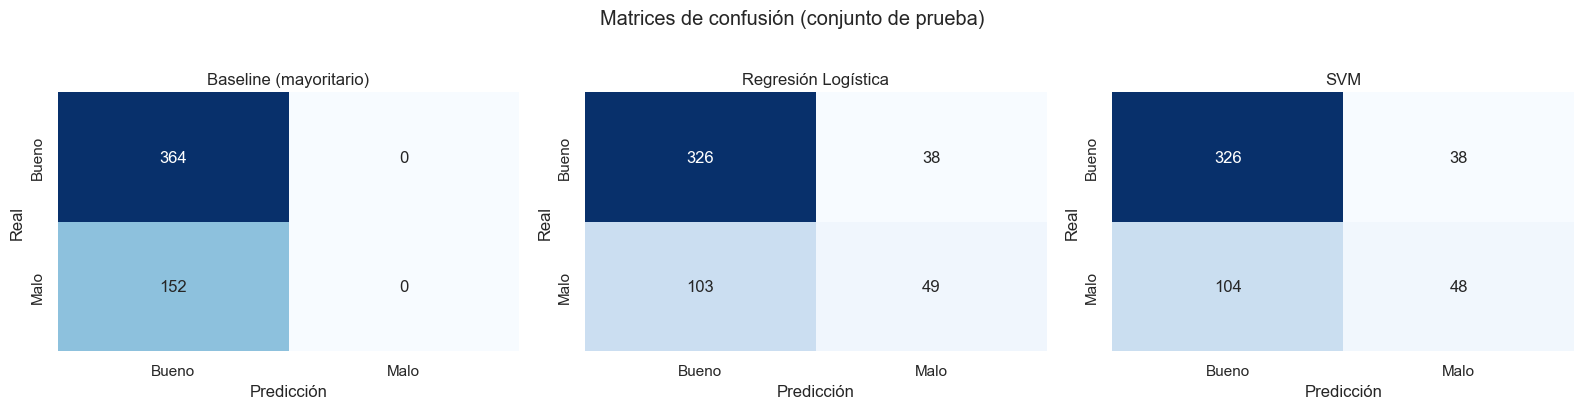

In [15]:
# Se visualizarán las matrices de confusión de los modelos.
fig, axes = plt.subplots(1, len(modelos), figsize=(16, 4))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Bueno', 'Malo'], yticklabels=['Bueno', 'Malo'])
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión (conjunto de prueba)', y=1.02)
plt.tight_layout()
plt.show()

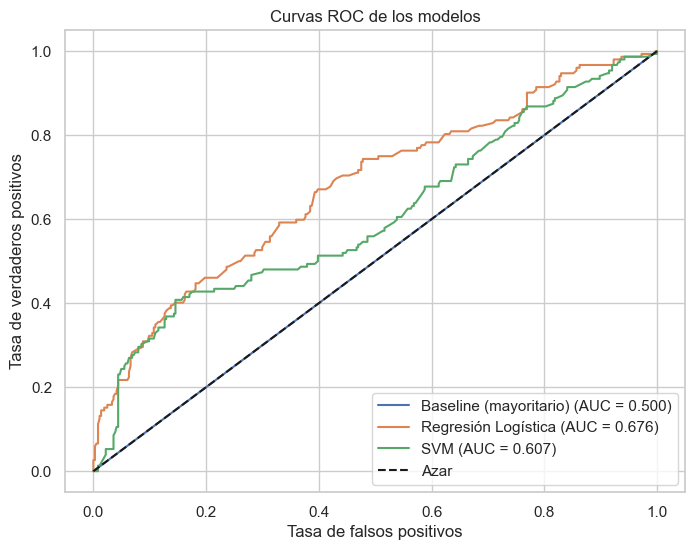

In [16]:
# Se compararán las curvas ROC de los modelos.
plt.figure(figsize=(8, 6))
for nombre, modelo in modelos.items():
    fpr, tpr, _ = roc_curve(y_test, puntuacion_positivo(modelo, X_test))
    auc_val = roc_auc_score(y_test, puntuacion_positivo(modelo, X_test))
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC de los modelos')
plt.legend(loc='lower right')
plt.show()

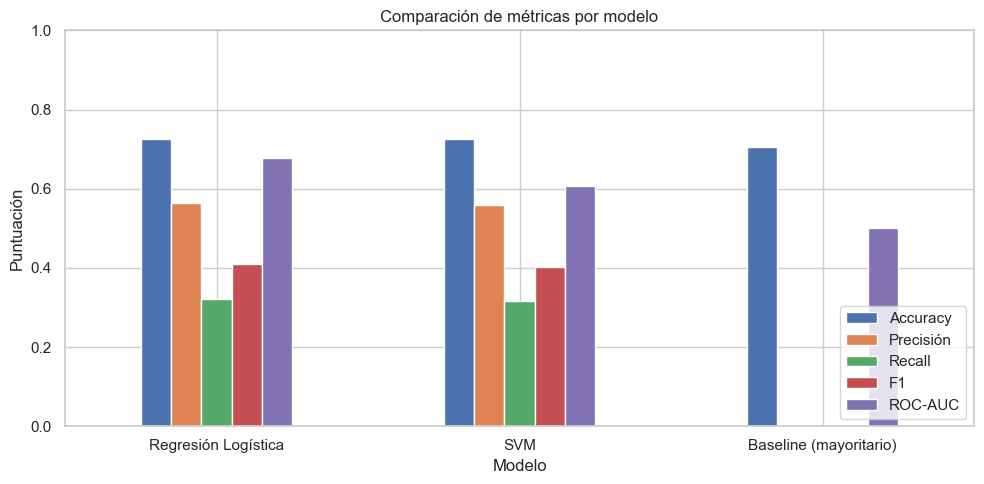

In [17]:
# Se generará un gráfico comparativo de las métricas por modelo.
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_resultados.set_index('Modelo')[['Accuracy', 'Precisión', 'Recall', 'F1', 'ROC-AUC']]
df_plot.plot(kind='bar', ax=ax, rot=0)
ax.set_title('Comparación de métricas por modelo')
ax.set_ylabel('Puntuación')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Conclusiones de la evaluación

- El **baseline** (predecir siempre "bueno") alcanza un **70,5% de exactitud** pero **no detecta ningún caso "malo"** (precision, recall y F1 en 0 para esa clase; AUC-ROC 0,50): es una referencia mínima e insuficiente.
- La **Regresión Logística** (C = 10) logra **0,73 de exactitud**, **F1 de 0,41** y **AUC-ROC de 0,68** en la clase "malo", superando claramente al baseline.
- El **SVM con kernel RBF** (C = 100, gamma = 'scale') logra resultados muy similares: **0,72 de exactitud**, **F1 de 0,40** y **AUC-ROC de 0,61**.
- Ambos modelos detectan alrededor del **32% de los ramen "malos"** reales (recall) con una precisión de ~56%, un rendimiento razonable considerando que la clase minoritaria representa solo el 29,5% de los datos.
- El **modelo ganador es la Regresión Logística**, por su mejor F1 y AUC-ROC. Resuelve el problema de negocio al identificar automáticamente productos de baja calidad a partir de marca, presentación y país de origen, algo que el baseline no logra.
- **Próximos pasos:** incorporar variables adicionales (precio, ingredientes), probar técnicas de balanceo de clases (SMOTE) y ajustar el umbral de decisión para mejorar el recall de la clase "malo".

In [18]:
# Se guardará el mejor modelo y el escalador en la carpeta models/ para su uso posterior.
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(mejor_modelo, 'models/mejor_modelo_ramen.joblib')
joblib.dump(scaler, 'models/scaler_ramen.joblib')

print('Modelo guardado en: models/mejor_modelo_ramen.joblib')
print('Escalador guardado en: models/scaler_ramen.joblib')

Modelo guardado en: models/mejor_modelo_ramen.joblib
Escalador guardado en: models/scaler_ramen.joblib
